<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding Duplicates Lab**


Estimated time needed: **30** minutes


## Introduction


Data wrangling is a critical step in preparing datasets for analysis, and handling duplicates plays a key role in ensuring data accuracy. In this lab, you will focus on identifying and removing duplicate entries from your dataset. 


## Objectives


In this lab, you will perform the following:


1. Identify duplicate rows in the dataset and analyze their characteristics.
2. Visualize the distribution of duplicates based on key attributes.
3. Remove duplicate values strategically based on specific criteria.
4. Outline the process of verifying and documenting duplicate removal.


## Hands on Lab


Install the needed library


In [27]:
!pip install pandas
!pip install matplotlib

Import pandas module


In [28]:
import pandas as pd


Import matplotlib


In [29]:
import matplotlib.pyplot as plt

## **Load the dataset into a dataframe**


<h2>Read Data</h2>
<p>
We utilize the <code>pandas.read_csv()</code> function for reading CSV files. However, in this version of the lab, which operates on JupyterLite, the dataset needs to be downloaded to the interface using the provided code below.
</p>


In [30]:
# Load the dataset directly from the URL
file_path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/VYPrOu0Vs3I0hKLLjiPGrA/survey-data-with-duplicate.csv"
df = pd.read_csv(file_path)

# Display the first few rows
print(df.head())

   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time        NaN  Apples   
4   Student, full-time        NaN  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                                NaN   
4                                 

Load the data into a pandas dataframe:



Note: If you are working on a local Jupyter environment, you can use the URL directly in the pandas.read_csv() function as shown below:



In [31]:
df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv")


## Identify and Analyze Duplicates


### Task 1: Identify Duplicate Rows
1. Count the number of duplicate rows in the dataset.
3. Display the first few duplicate rows to understand their structure.


In [32]:
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


In [33]:
df_no_id = df.drop(columns=['ResponseId'])
print(df_no_id.duplicated().sum())
print(df_no_id[df_no_id.duplicated()].head())

487
                                              MainBranch                 Age  \
46264                     I am a developer by profession     25-34 years old   
46774                     I am a developer by profession     18-24 years old   
46921                     I am a developer by profession     18-24 years old   
47073  I am not primarily a developer, but I write co...     25-34 years old   
47340                        I code primarily as a hobby  Under 18 years old   

                Employment                            RemoteWork   Check  \
46264  Employed, full-time                                Remote  Apples   
46774  Employed, full-time  Hybrid (some remote, some in-person)  Apples   
46921  Employed, full-time                             In-person  Apples   
47073  Employed, full-time                             In-person  Apples   
47340   Student, full-time                                   NaN  Apples   

                                        CodingActivities E

### Task 2: Analysis of Duplicate Response Patterns
1. Identify duplicate response patterns based on selected columns such as MainBranch, Employment, and RemoteWork.
2. Clarify that these represent multiple respondents with identical answers rather than duplicate records. Analyse which other columns frequently share identical values within these response-pattern groups.
   


In [34]:
pattern_counts = df.groupby(['MainBranch', 'Employment', 'RemoteWork']).size().reset_index(name='count')

# show only repeated patterns
duplicate_patterns = pattern_counts[pattern_counts['count'] > 1].sort_values(by='count', ascending=False)

print(duplicate_patterns.head(10))

                                            MainBranch  \
0                       I am a developer by profession   
2                       I am a developer by profession   
1                       I am a developer by profession   
78                      I am a developer by profession   
8                       I am a developer by profession   
232  I am not primarily a developer, but I write co...   
6                       I am a developer by profession   
76                      I am a developer by profession   
233  I am not primarily a developer, but I write co...   
234  I am not primarily a developer, but I write co...   

                                            Employment  \
0                                  Employed, full-time   
2                                  Employed, full-time   
1                                  Employed, full-time   
78   Independent contractor, freelancer, or self-em...   
8    Employed, full-time;Independent contractor, fr...   
232          

In [35]:
top_pattern = duplicate_patterns.iloc[0]

subset = df[
    (df['MainBranch'] == top_pattern['MainBranch']) &
    (df['Employment'] == top_pattern['Employment']) &
    (df['RemoteWork'] == top_pattern['RemoteWork'])
]

print(subset.head())

    ResponseId                      MainBranch              Age  \
12          13  I am a developer by profession  35-44 years old   
14          15  I am a developer by profession  25-34 years old   
15          16  I am a developer by profession  45-54 years old   
18          19  I am a developer by profession  25-34 years old   
19          20  I am a developer by profession  35-44 years old   

             Employment                            RemoteWork   Check  \
12  Employed, full-time  Hybrid (some remote, some in-person)  Apples   
14  Employed, full-time  Hybrid (some remote, some in-person)  Apples   
15  Employed, full-time  Hybrid (some remote, some in-person)  Apples   
18  Employed, full-time  Hybrid (some remote, some in-person)  Apples   
19  Employed, full-time  Hybrid (some remote, some in-person)  Apples   

                                     CodingActivities  \
12  Hobby;Contribute to open-source projects;Profe...   
14  Hobby;Professional development or self-p

In [36]:
subset.nunique().sort_values()

MainBranch                     1
Employment                     1
RemoteWork                     1
Check                          1
TBranch                        2
                           ...  
ToolsTechWantToWorkWith     5432
LanguageWantToWorkWith      6301
ToolsTechHaveWorkedWith     6484
LanguageHaveWorkedWith      6743
ResponseId                 15286
Length: 114, dtype: int64

### Task 3: Visualize Shared Response Patterns
1. Create visualizations to show the distribution of shared response patterns across different categories.
2. Use bar charts or pie charts to represent the distribution of respondents who share identical values for MainBranch, Employment, and RemoteWork, grouped by Country and Employment.


In [37]:
### Task 3: Visualize Shared Response Patterns
grouped = df.groupby(['Country', 'Employment']).size().reset_index(name='count')
grouped = grouped.sort_values(by='count', ascending=False)

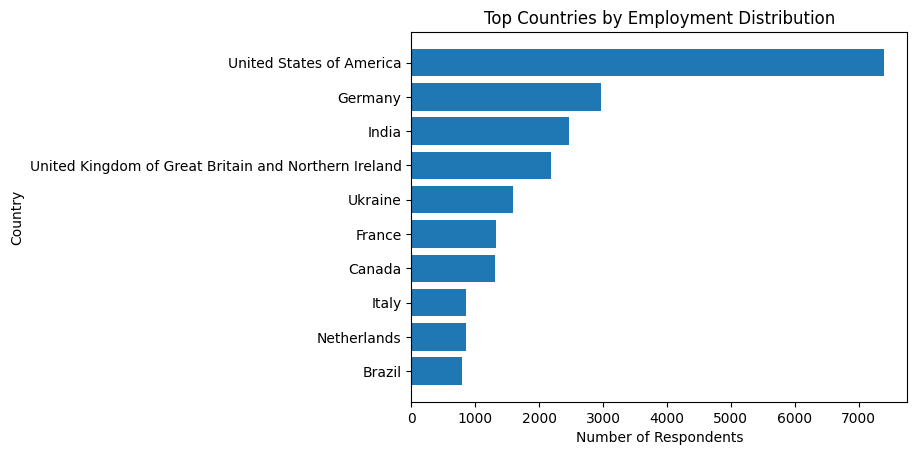

In [25]:
import matplotlib.pyplot as plt

top_data = grouped.head(10)

plt.figure()
plt.barh(top_data['Country'], top_data['count'])
plt.xlabel('Number of Respondents')
plt.ylabel('Country')
plt.title('Top Countries by Employment Distribution')
plt.gca().invert_yaxis()
plt.show()

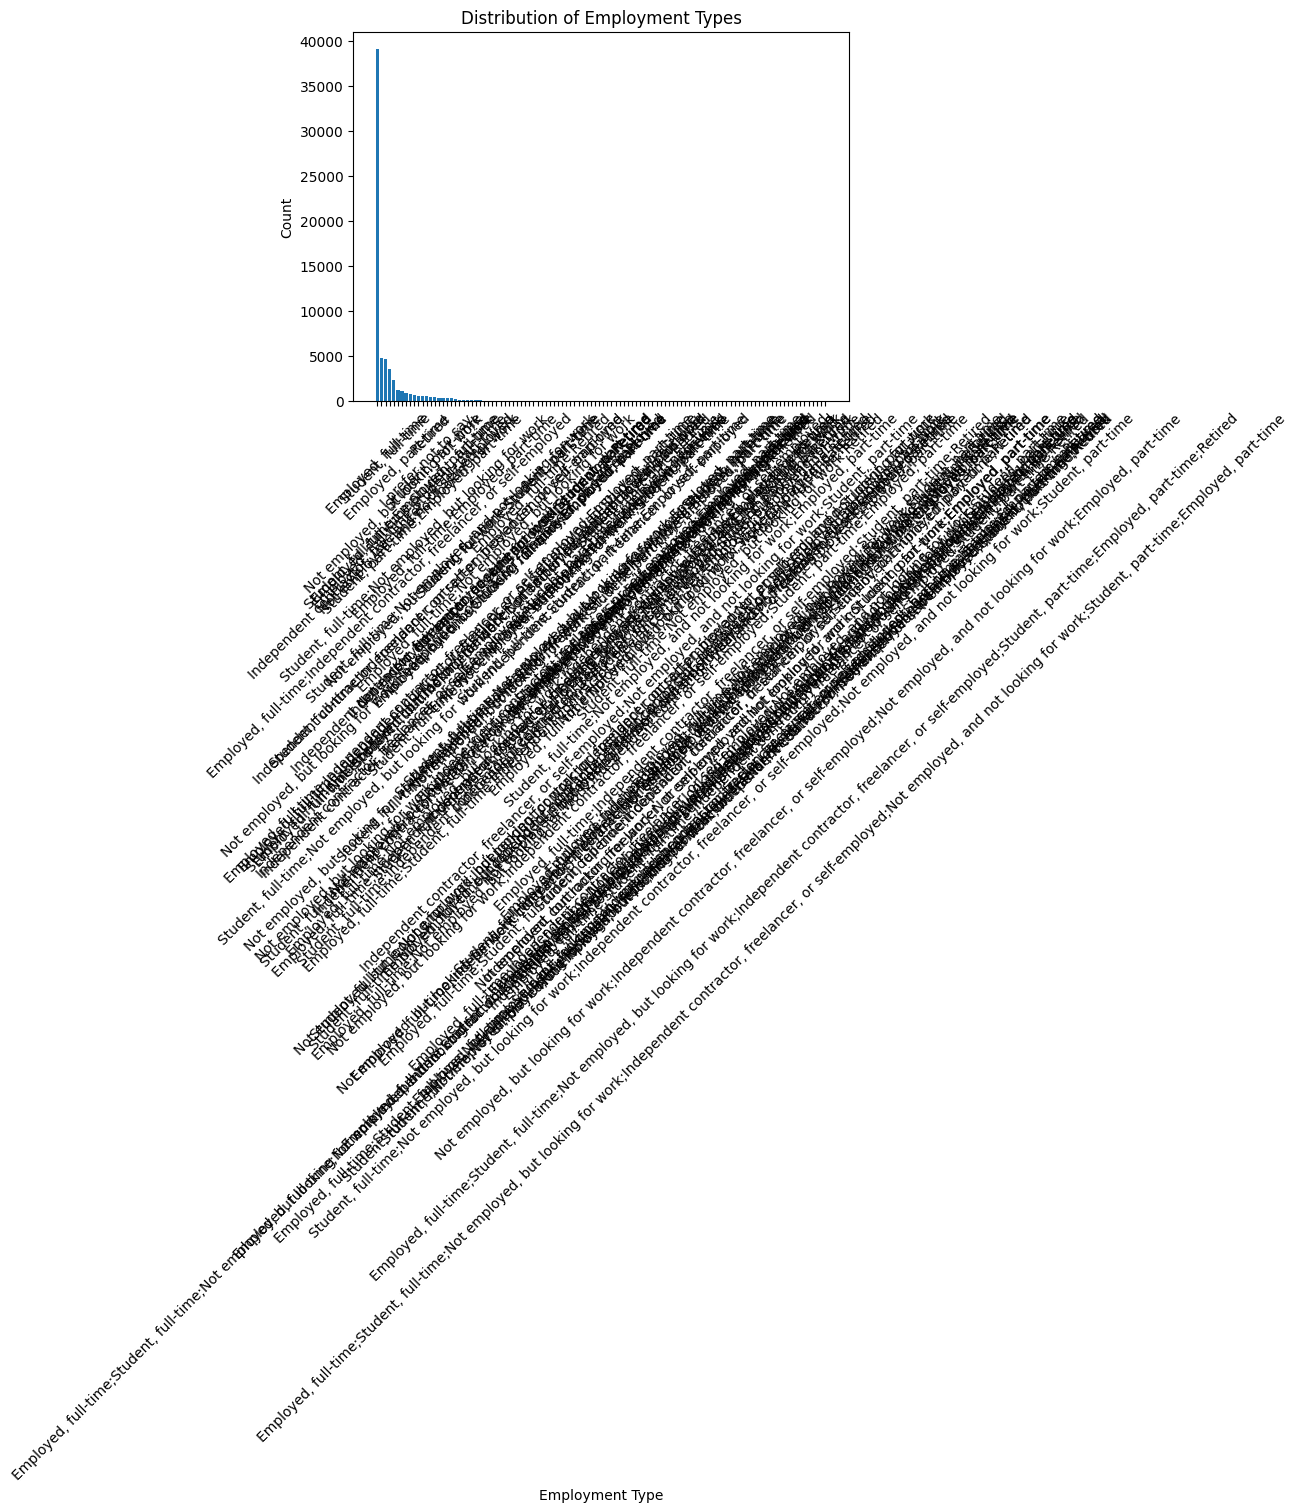

In [26]:
emp_counts = df['Employment'].value_counts()

plt.figure()
plt.bar(emp_counts.index, emp_counts.values)
plt.xticks(rotation=45)
plt.xlabel('Employment Type')
plt.ylabel('Count')
plt.title('Distribution of Employment Types')
plt.show()

### Task 4: Evaluate Duplicate Handling Strategy
1. Analyse the dataset to determine which column(s) define record uniqueness.
2. Assess whether removing rows based on a subset of columns (rather than complete row duplication) is appropriate.
Justify your decision with reference to the structure and purpose of the dataset.


## Verify and Document Duplicate Removal Process


### Task 5: Documentation
1. Document the process of identifying and removing duplicates.


- Duplicate rows were checked using `df.duplicated()`, and none were found.
- Patterns were further analyzed using grouping on `MainBranch`, `Employment`, and `RemoteWork`, revealing repeated responses from different individuals.
- `ResponseId` was confirmed as a unique identifier for each record.
- No rows were removed, as duplicates did not exist and subset-based removal would eliminate valid data.

2. Explain the reasoning behind selecting specific columns for identifying and removing duplicates.


* All columns were initially considered to check for complete duplicate rows, ensuring data integrity.
* `ResponseId` was used to confirm uniqueness, as it uniquely identifies each respondent.
* Selected columns like `MainBranch`, `Employment`, and `RemoteWork` were used only to analyze response patterns, not for removal.
* These columns were chosen because they represent key survey attributes, but duplicates based on them were not removed since they reflect valid responses from different individuals.


### Summary and Next Steps
**In this lab, you focused on identifying and analyzing duplicate rows within the dataset.**

- You employed various techniques to explore the nature of duplicates and applied strategic methods for their removal.
- For additional analysis, consider investigating the impact of duplicates on specific analyses and how their removal affects the results.
- This version of the lab is more focused on duplicate analysis and handling, providing a structured approach to deal with duplicates in a dataset effectively.


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2024-11- 05|1.3|Madhusudhan Moole|Updated lab|
|2024-10-28|1.2|Madhusudhan Moole|Updated lab|
|2024-09-24|1.1|Madhusudhan Moole|Updated lab|
|2024-09-23|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
